# 07. MCP 에이전트 통합 (MCP Agent Integration)

> **왜 에이전트 통합이 중요한가요?**
>
> MCP 서버를 만드는 것은 도구를 "만드는" 단계예요. 하지만 도구가 아무리 좋아도 에이전트에 연결하지 않으면 쓸모가 없어요. 이 노트북에서는 MCP 도구를 에이전트에 연결해서 **에이전트가 스스로 적절한 도구를 선택하고 사용**하게 만드는 방법을 배워요.

이전 노트북(`06-MCP-Server-Basics.ipynb`)에서는 FastMCP로 서버를 만드는 방법을 배웠어요. 이번에는 그 서버들을 **에이전트에 연결**하는 방법을 살펴볼게요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `MultiServerMCPClient`로 여러 MCP 서버를 동시에 관리할 수 있어요
2. `create_agent`와 MCP 도구를 조합해 대화형 에이전트를 만들 수 있어요
3. `ToolNode` + `StateGraph`로 세밀하게 제어 가능한 MCP 워크플로우를 구성할 수 있어요
4. stdio 서버(날씨)와 HTTP 서버(시간)를 동시에 활용하는 다중 서버 에이전트를 구현할 수 있어요

## 사전 지식

- `06-MCP-Server-Basics.ipynb` — FastMCP 서버 생성, stdio/HTTP 전송 방식
- LangGraph StateGraph, ToolNode, tools_condition
- `create_agent`와 InMemorySaver 사용법
- Python `async`/`await`와 이벤트 루프 기초 — MCP 클라이언트는 비동기예요 (아래 `run_async` 헬퍼로 Jupyter에서 안전하게 호출해요)

## MCP 에이전트 통합 아키텍처

MCP 에이전트 통합은 두 가지 방식으로 구현할 수 있어요.

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"])
    A1["create_agent<br>고수준 에이전트"]
    A2["StateGraph + ToolNode<br>저수준 커스텀 워크플로우"]
    MC["MultiServerMCPClient<br>다중 서버 관리자"]
    S1["stdio 서버<br>(날씨 정보)"]
    S2["HTTP 서버<br>(현재 시간)"]
    S3["stdio 서버<br>(RAG 검색)"]
    R(["에이전트 응답<br>Agent Response"])

    U --> A1
    U --> A2
    A1 --> MC
    A2 --> MC
    MC --> S1
    MC --> S2
    MC --> S3
    A1 --> R
    A2 --> R

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class U,R input
    class A1,A2 process
    class MC process
    class S1,S2,S3 storage
```

| 방식 | 클래스 | 특징 | 적합한 상황 |
|------|--------|------|------------|
| 고수준 | `create_agent` | 자동 추론-행동 루프 | 빠른 프로토타이핑, 표준 ReAct 패턴 |
| 저수준 | `StateGraph` + `ToolNode` | 노드별 세밀 제어 | 복잡한 분기, 커스텀 로직 |

> 🔑 **핵심 개념**: `MultiServerMCPClient`는 여러 MCP 서버를 하나로 묶어주는 **통합 관리자**예요.

> 💡 **어떤 방식을 선택해야 할까요?**
> - **빠른 프로토타입이 필요하다면** → `create_agent` (코드 5줄로 완성)
> - **조건부 분기, 커스텀 로직이 필요하다면** → `StateGraph + ToolNode` (세밀 제어) 서버마다 다른 전송 방식(stdio, HTTP)을 사용해도 `get_tools()`로 일관되게 도구를 가져올 수 있어요.

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 읽어와요)
from dotenv import load_dotenv

load_dotenv()

# LangSmith 추적 설정 (선택사항 - 에이전트 실행 과정을 시각적으로 확인할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-MCP-Agent"

## Jupyter에서 비동기 MCP 호출하기: `run_async` 헬퍼

MCP 클라이언트(`MultiServerMCPClient`)는 **비동기(async)** 라서 `await`로 호출해야 해요. 그런데 Jupyter는 이미 자체 이벤트 루프 위에서 돌아가기 때문에, 그 안에서 또 다른 비동기 코드를 직접 실행하면 충돌이 날 수 있어요.

아래 `run_async(coro)` 헬퍼는 **별도 스레드에서 새 이벤트 루프를 만들어** 코루틴을 안전하게 실행해줘요. 동작 원리를 깊이 이해하지 않아도 괜찮아요 — 이 셀을 **그대로 복사해 두고**, 이후 비동기 호출은 `run_async(...)`로 감싸 쓰면 돼요.


In [2]:
# Jupyter 환경에서 비동기 MCP 클라이언트를 안전하게 실행하기 위한 헬퍼예요
# anyio가 asyncio 이벤트 루프 내부에서 직접 실행될 때 충돌이 발생하므로,
# 별도 스레드에서 새 이벤트 루프를 생성해 안전하게 실행해요
import asyncio
from concurrent.futures import ThreadPoolExecutor

def run_async(coro):
    """별도 스레드에서 새 이벤트 루프를 생성해 코루틴을 실행하는 헬퍼예요."""
    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(coro)
        finally:
            loop.close()
    
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(run_in_thread)
        return future.result()

# run_async() 헬퍼 정의 완료

---

## 1. MultiServerMCPClient 설정

`MultiServerMCPClient`는 여러 MCP 서버를 동시에 관리하는 클라이언트예요. 각 서버의 도구를 하나의 도구 목록으로 통합해서 에이전트에 전달해줘요.

### 지원하는 전송 방식

| 전송 방식 | 설정 키 | 특징 | 사용 시나리오 |
|----------|---------|------|---------------|
| `stdio` | `command`, `args` | 서버를 서브프로세스로 실행 | 로컬 Python 스크립트 |
| `streamable_http` | `url` | HTTP 엔드포인트로 연결 | 원격 서버, 이미 실행 중인 서버 |

> 🎯 **강의 포인트**: `stdio` 방식은 클라이언트가 서버 프로세스를 직접 관리해요. 별도 터미널에서 서버를 켤 필요가 없어서 편리하지만, 서버가 Python 실행 환경에 있어야 해요.

In [3]:
# ---------------------------------------------------
# MCP 클라이언트 핵심 임포트
# ---------------------------------------------------
# MultiServerMCPClient: 여러 MCP 서버를 동시에 관리하는 클라이언트
from langchain_mcp_adapters.client import MultiServerMCPClient


async def setup_mcp_client(server_configs: dict) -> tuple:
    """MCP 클라이언트를 설정하고 도구 목록을 가져오는 헬퍼 함수예요.

    Args:
        server_configs: 서버 구성 딕셔너리
            - 키: 서버 이름 (식별용)
            - 값: 연결 정보 (command+args+transport 또는 url+transport)

    Returns:
        tuple: (MCP 클라이언트, 도구 목록)
    """
    # MultiServerMCPClient로 여러 서버를 하나의 클라이언트로 관리해요
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 모든 도구 목록을 가져와요
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력해서 확인해요
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}: {tool.description[:50] if tool.description else '(설명 없음)'}")

    return client, tools

### 1-1. stdio 전송 방식으로 날씨 서버 연결

stdio 방식은 `command`와 `args`로 서버 스크립트를 직접 실행해요. 클라이언트가 서버 프로세스의 수명 주기를 자동으로 관리해줘요.

> ⚠️ **자주 하는 실수**: `args`에서 서버 파일 경로는 **노트북 실행 위치 기준**이에요. 노트북을 다른 디렉토리에서 실행하면 경로 오류가 발생해요. 절대 경로를 사용하거나 `os.path`로 경로를 구성하면 안전해요.

In [4]:
# ---------------------------------------------------
# stdio 전송 방식으로 날씨 MCP 서버 연결하기
# ---------------------------------------------------
# 날씨 서버: servers/01_weather_server.py를 서브프로세스로 실행해요
# transport: "stdio" - 표준 입출력으로 통신
weather_server_config = {
    "weather": {
        "command": "uv",  # uv로 Python 환경을 관리해요
        "args": ["run", "python", "servers/01_weather_server.py"],  # 서버 스크립트 경로
        "transport": "stdio",  # stdio 전송 방식
    },
}

# MCP 클라이언트를 생성하고 도구를 로드해요
# run_async()로 별도 스레드에서 실행해 anyio 충돌을 방지해요
client, weather_tools = run_async(setup_mcp_client(server_configs=weather_server_config))

[MCP] 1개의 도구가 로드되었습니다:
  - get_weather: 지정한 도시의 현재 날씨를 조회해요.

Args:
    location: 날씨를 조회할 


### 1-2. HTTP 전송 방식으로 시간 서버 연결

HTTP 방식은 이미 실행 중인 서버의 URL로 연결해요. 먼저 별도 터미널에서 서버를 실행해야 해요:

```bash
uv run python servers/02_time_server.py
```

> 💡 **실무 팁**: HTTP 방식은 서버를 별도 인프라로 배포할 때 유용해요. 마이크로서비스 아키텍처에서 각 MCP 서버를 독립적으로 배포하고 확장할 수 있어요.

In [5]:
# ---------------------------------------------------
# streamable_http 전송 방식으로 시간 MCP 서버 연결하기
# ---------------------------------------------------
# 주의: 아래 코드를 실행하기 전에 별도 터미널에서 시간 서버를 실행해야 해요:
# $ uv run python servers/02_time_server.py

time_server_config = {
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",  # HTTP 엔드포인트 URL
        "transport": "streamable_http",  # HTTP 스트리밍 전송 방식
    },
}

# HTTP 서버에 연결하여 도구를 로드해요
# (서버가 실행 중이지 않으면 연결 오류가 발생해요)
try:
    client_http, time_tools = run_async(setup_mcp_client(server_configs=time_server_config))
except Exception as e:
    print(f"시간 서버 연결 실패 (서버가 실행 중이지 않음): {e}")
    # 다음 실습을 위해 시간 서버 없이 진행해요.
    time_tools = []

[MCP] 1개의 도구가 로드되었습니다:
  - get_current_time: 지정한 시간대의 현재 시간을 조회해요.

Args:
    timezone: 조회할 시간대


---

## 2. create_agent + MCP 도구

`create_agent`는 LangChain V1의 고수준 에이전트 생성 함수예요. LLM과 도구 목록을 전달하면 ReAct 패턴(추론 → 행동 → 관찰 반복)을 자동으로 구현해줘요.

> 🔑 **핵심 개념**: `InMemorySaver`를 `checkpointer`로 전달하면 에이전트가 **대화 상태를 메모리에 유지**해요. 같은 `thread_id`로 여러 번 호출하면 이전 대화를 기억해요.

In [6]:
# ---------------------------------------------------
# create_agent로 MCP 날씨 에이전트 만들기
# ---------------------------------------------------
# LangChain V1의 에이전트 생성 함수와 체크포인터를 가져와요
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import InMemorySaver

# 기본 모델: gpt-4o-mini (비용 효율적, 학생 접근성 높음)
# 변경 옵션: "anthropic:claude-sonnet-4-5", "ollama:llama3"
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# create_agent로 MCP 날씨 도구를 사용하는 에이전트를 만들어요
# checkpointer: 대화 상태를 메모리에 저장 (thread_id로 구분)
weather_agent = create_agent(
    llm,
    weather_tools+time_tools,  # MCP 서버에서 가져온 도구 목록
    checkpointer=InMemorySaver(),  # 대화 히스토리 유지
)

# 에이전트 생성 완료!

In [7]:
# ---------------------------------------------------
# 에이전트 실행 - 스트리밍으로 결과 확인하기
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

# 대화 스레드 ID를 생성해요 (같은 ID로 연속 호출하면 대화가 이어져요)
thread_id = str(uuid.uuid4())
config = RunnableConfig(configurable={"thread_id": thread_id})

# 에이전트 실행 결과를 스트리밍으로 출력해요
# ==================================================
# 날씨 에이전트 실행 중...
# ==================================================

async def run_weather_agent():
    async for chunk in weather_agent.astream(
        {"messages": [("human", "안녕하세요. 현재 서울의 시간과 서울의 날씨를 알려주세요.")]},
        config,
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- {node_name} ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_weather_agent())


--- model ---
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_PhivAqTgrANI0YPAvHFQbvKK)
 Call ID: call_PhivAqTgrANI0YPAvHFQbvKK
  Args:
    timezone: Asia/Seoul
  get_weather (call_BHXHfVdUV7l35xKXB5KM99VL)
 Call ID: call_BHXHfVdUV7l35xKXB5KM99VL
  Args:
    location: 서울

--- tools ---
================================= Tool Message =================================
Name: get_current_time

[{'type': 'text', 'text': '현재 Asia/Seoul 시간: 2026-06-02 13:46:00 KST', 'id': 'lc_b1b800d1-7a2c-4d3c-bb3f-63a5aee1b29d'}]

--- tools ---
================================= Tool Message =================================
Name: get_weather

[{'type': 'text', 'text': "It's always Sunny in 서울", 'id': 'lc_c2e5b7f4-307f-4290-b95c-619839b4ddb6'}]

--- model ---
================================== Ai Message ==================================

현재 서울의 시간은 **2026-06-02 13:46:00 KST**입니다.  
서울의 날씨는 **항상 맑습니다**.


### 2-1. 대화 컨텍스트 유지 확인

같은 `thread_id`로 추가 질문을 하면 이전 대화 내용을 기억해요.

In [8]:
# ---------------------------------------------------
# 같은 thread_id로 연속 대화 - 컨텍스트 유지 확인
# ---------------------------------------------------
# 같은 config (동일 thread_id)를 사용하므로 이전 대화를 기억해요
# ==================================================
# 이전 대화를 기억하는지 확인 중...
# ==================================================

async def run_weather_agent_followup():
    async for chunk in weather_agent.astream(
        {"messages": [("human", "방금 알려준 도시의 날씨가 맑다면, 지금 시간대에 할만한 야외 활동을 추천해줘요.")]},
        config,  # 같은 thread_id 사용 - 이전 대화 내용 포함
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- {node_name} ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_weather_agent_followup())


--- model ---
================================== Ai Message ==================================

서울의 날씨가 맑다면 다음과 같은 야외 활동을 추천합니다:

1. **한강 공원 산책**: 한강을 따라 산책하거나 자전거를 타며 경치를 즐길 수 있습니다.
2. **등산**: 북한산이나 관악산 등 근처의 산에서 하이킹을 즐길 수 있습니다.
3. **피크닉**: 공원이나 한강변에서 친구나 가족과 함께 피크닉을 즐기세요.
4. **야외 카페 방문**: 야외 테라스가 있는 카페에서 커피를 마시며 여유로운 시간을 보낼 수 있습니다.
5. **문화 행사 참여**: 서울에서는 종종 야외에서 열리는 문화 행사나 공연이 있으니, 일정을 확인해 보세요.

맑은 날씨를 만끽하며 즐거운 시간을 보내세요!


---

## 3. RAG MCP 서버 연결

RAG(Retrieval-Augmented Generation) MCP 서버는 외부 문서에서 관련 정보를 검색하는 기능을 제공해요. MCP를 통해 RAG 기능을 표준화하면 에이전트가 다양한 문서 소스에 접근할 수 있어요.

```mermaid
flowchart LR
    Q(["사용자 질문"])
    AG["에이전트<br>(gpt-4o-mini)"]
    MC["MCP 클라이언트"]
    RS["RAG MCP 서버<br>(stdio)"]
    VDB[("벡터 DB<br>(FAISS)")]
    PDF[("PDF 문서")]
    ANS(["검색 기반 답변"])

    Q --> AG
    AG -->|"retrieve 도구 호출"| MC
    MC --> RS
    RS --> VDB
    VDB --> PDF
    PDF -->|"관련 청크 반환"| VDB
    VDB -->|"검색 결과"| RS
    RS -->|"문서 내용"| MC
    MC -->|"ToolMessage"| AG
    AG --> ANS

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class Q,ANS input
    class AG,MC,RS process
    class VDB,PDF storage
```

> 💡 **실무 팁**: RAG 기능을 MCP 서버로 분리하면 **에이전트 코드와 검색 로직을 분리**할 수 있어요. 나중에 검색 엔진을 FAISS에서 Pinecone으로 바꿀 때 에이전트 코드를 수정할 필요가 없어요.

In [9]:
# ---------------------------------------------------
# RAG MCP 서버 연결 및 에이전트 생성
# ---------------------------------------------------
# RAG 서버: PDF 문서를 벡터 DB에 저장하고 검색 기능을 제공해요
rag_server_config = {
    "rag": {
        "command": "uv",
        "args": ["run", "python", "servers/05_rag_server.py"],  # RAG 서버 스크립트
        "transport": "stdio",
    },
}

# RAG 도구 로드
try:
    client_rag, rag_tools = run_async(setup_mcp_client(server_configs=rag_server_config))
    
    # RAG 도구를 사용하는 에이전트 생성
    rag_agent = create_agent(
        init_chat_model("openai:gpt-4o-mini", temperature=0),
        rag_tools,
        checkpointer=InMemorySaver(),
    )
    # RAG 에이전트 생성 완료!
    rag_available = True
except Exception as e:
    print(f"RAG 서버 연결 실패: {e}")
    # RAG 서버를 건너뛰고 진행해요.
    rag_available = False

[MCP] 2개의 도구가 로드되었습니다:
  - retrieve: 쿼리와 가장 관련있는 문서 청크를 검색하여 반환해요.

FAISS 벡터 DB에서 코사인 유
  - get_retriever_status: RAG 서버의 상태와 로드된 문서 정보를 반환해요.

Returns:
    서버 상태 정


In [10]:
# ---------------------------------------------------
# RAG 에이전트 실행 - 문서 검색 테스트
# ---------------------------------------------------
if not rag_available:
    # RAG 서버가 실행되지 않아 이 셀을 건너뛰어요.
    # 05_rag_server.py가 필요한 패키지(langchain, faiss-cpu 등)를 설치 후 직접 실행해보세요.
    pass
else:
    # 새로운 대화 스레드로 시작해요
    rag_thread_id = str(uuid.uuid4())
    rag_config = RunnableConfig(configurable={"thread_id": rag_thread_id})

    # ==================================================
    # RAG 에이전트 실행 중...
    # ==================================================

    async def run_rag_agent():
        # MCP RAG 서버를 통해 PDF 문서에서 삼성 가우스 정보 검색
        async for chunk in rag_agent.astream(
            {
                "messages": [
                    (
                        "human",
                        "삼성전자가 개발한 생성형 AI의 이름은 무엇인가요? MCP 서버를 사용해서 검색해주세요.",
                    )
                ]
            },
            rag_config,
            stream_mode="updates",
        ):
            for node_name, node_output in chunk.items():
                print(f"\n--- {node_name} ---")
                if "messages" in node_output:
                    for msg in node_output["messages"]:
                        msg.pretty_print()

    run_async(run_rag_agent())


--- model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_IunAXiHNqW7S5kYma5k3CbkY)
 Call ID: call_IunAXiHNqW7S5kYma5k3CbkY
  Args:
    query: 삼성전자 생성형 AI 이름

--- tools ---
================================= Tool Message =================================
Name: retrieve

[{'type': 'text', 'text': '[출처: SPRI_AI_Brief_2023년12월호_F.pdf, 12페이지] SPRi AI Brief |  \n2023-12월호\n10\n삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개\nn 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성 \nAI 모델 ‘삼성 가우스’를 공개\nn 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한 \n삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유\nKEY Contents\n£ 언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원\nn 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’ 행사에서 자체 개발한 생성 AI 모델 \n‘삼성 가우스’를 최초 공개\n∙정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에 \n최적화된 크기의 모델 선택이 가능\n∙삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,\n\n[출처: SPRI_AI_Brief_2023년12월호_F.pdf, 12페이지] 저해상도 이미지의 고해상도 전환도 지원\nn IT 전문지 테크리퍼블릭(

---

## 4. 다중 MCP 서버 조합

하나의 에이전트에서 여러 MCP 서버를 동시에 사용할 수 있어요. `MultiServerMCPClient`가 각 서버의 도구를 하나로 합쳐줘요.

> 🎯 **강의 포인트**: 이 부분을 라이브로 시연하면서 `get_tools()` 반환값에 **두 서버의 도구가 모두 포함**되는 것을 보여주세요. 에이전트는 질문에 따라 적절한 도구를 자동으로 선택해요.

In [11]:
# ---------------------------------------------------
# 다중 서버 구성: stdio(날씨) + HTTP(시간) 동시 연결
# ---------------------------------------------------
# 주의: HTTP 서버(02_time_server.py)는 별도 터미널에서 미리 실행해야 해요
multi_server_config = {
    # 날씨 서버: stdio 방식 (서브프로세스로 자동 관리)
    "weather": {
        "command": "uv",
        "args": ["run", "python", "servers/01_weather_server.py"],
        "transport": "stdio",
    },
    # 시간 서버: HTTP 방식 (별도 서버 프로세스 필요)
    "current_time": {
        "url": "http://127.0.0.1:8002/mcp",
        "transport": "streamable_http",
    },
}

# 두 서버의 도구를 한 번에 로드해요
# get_tools()가 모든 서버의 도구를 합쳐서 반환해요
try:
    multi_client, multi_tools = run_async(setup_mcp_client(server_configs=multi_server_config))
except Exception as e:
    print(f"다중 서버 연결 실패 (HTTP 서버가 실행 중이지 않을 수 있어요): {e}")
    # 날씨 서버만 사용해 진행해요.
    # 날씨 서버만 사용해요
    multi_server_config = {
        "weather": {
            "command": "uv",
            "args": ["run", "python", "servers/01_weather_server.py"],
            "transport": "stdio",
        },
    }
    multi_client, multi_tools = run_async(setup_mcp_client(server_configs=multi_server_config))

[MCP] 2개의 도구가 로드되었습니다:
  - get_weather: 지정한 도시의 현재 날씨를 조회해요.

Args:
    location: 날씨를 조회할 
  - get_current_time: 지정한 시간대의 현재 시간을 조회해요.

Args:
    timezone: 조회할 시간대


In [12]:
# ---------------------------------------------------
# 다중 서버 에이전트 생성 헬퍼 함수
# ---------------------------------------------------
async def create_mcp_agent(server_configs: dict):
    """MCP 도구를 사용하는 에이전트를 생성하는 헬퍼 함수예요.

    Args:
        server_configs: MCP 서버 구성 딕셔너리

    Returns:
        컴파일된 에이전트
    """
    # 서버에서 도구를 가져와요
    _, tools = await setup_mcp_client(server_configs=server_configs)

    # gpt-4o-mini 모델과 InMemorySaver로 에이전트를 생성해요
    agent = create_agent(
        init_chat_model("openai:gpt-4o-mini", temperature=0),
        tools,
        checkpointer=InMemorySaver(),
    )

    return agent


# 다중 서버를 사용하는 에이전트를 만들어요
multi_agent = run_async(create_mcp_agent(multi_server_config))
# 다중 서버 에이전트 생성 완료!

[MCP] 2개의 도구가 로드되었습니다:
  - get_weather: 지정한 도시의 현재 날씨를 조회해요.

Args:
    location: 날씨를 조회할 
  - get_current_time: 지정한 시간대의 현재 시간을 조회해요.

Args:
    timezone: 조회할 시간대


In [13]:
# ---------------------------------------------------
# 다중 서버 에이전트 실행: 시간 + 날씨 연속 질문
# ---------------------------------------------------
# 같은 thread_id로 두 번 질문 - 에이전트가 적절한 서버를 자동 선택해요
multi_thread_id = str(uuid.uuid4())
multi_config = RunnableConfig(configurable={"thread_id": multi_thread_id})

# ==================================================
# [질문 1] 현재 시간 요청
# ==================================================

async def run_multi_agent_q1():
    # 첫 번째 질문: 시간 서버 도구를 자동 선택
    async for chunk in multi_agent.astream(
        {"messages": [("human", "지금 몇 시예요?")]},
        multi_config,
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- {node_name} ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_multi_agent_q1())


--- model ---
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_qPgLPW9qVs9YEv1kzobxU2od)
 Call ID: call_qPgLPW9qVs9YEv1kzobxU2od
  Args:

--- tools ---
================================= Tool Message =================================
Name: get_current_time

[{'type': 'text', 'text': '현재 Asia/Seoul 시간: 2026-06-02 13:46:13 KST', 'id': 'lc_b5fe7867-745f-4bb0-839b-87125a704e38'}]

--- model ---
================================== Ai Message ==================================

현재 서울의 시간은 2026년 6월 2일 13시 46분 13초입니다.


In [14]:
# ---------------------------------------------------
# 두 번째 질문: 같은 스레드에서 날씨 도구를 자동 선택
# ---------------------------------------------------
# ==================================================
# [질문 2] 날씨 요청 (이전 대화 컨텍스트 유지)
# ==================================================

async def run_multi_agent_q2():
    async for chunk in multi_agent.astream(
        {"messages": [("human", "서울 날씨는 어때요?")]},
        multi_config,  # 같은 thread_id - 이전 대화 기억
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- {node_name} ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_multi_agent_q2())


--- model ---
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_qsL9OtANDNsSlJ5ZdfAcIcat)
 Call ID: call_qsL9OtANDNsSlJ5ZdfAcIcat
  Args:
    location: 서울

--- tools ---
================================= Tool Message =================================
Name: get_weather

[{'type': 'text', 'text': "It's always Sunny in 서울", 'id': 'lc_f0ae973c-5eac-4234-85b4-98f5b385a2c4'}]

--- model ---
================================== Ai Message ==================================

서울의 날씨는 맑습니다.


---

## 5. ToolNode + StateGraph로 커스텀 MCP 워크플로우

`create_agent`는 편리하지만 내부 동작을 제어하기 어려워요. `StateGraph`와 `ToolNode`를 직접 사용하면 **각 노드의 동작을 완전히 제어**할 수 있어요.

```mermaid
flowchart TD
    ST(["START"])
    AG["agent 노드<br>(LLM 추론)"]
    TN["tools 노드<br>(ToolNode - MCP 실행)"]
    EN(["END"])

    ST --> AG
    AG -->|"도구 호출 있음<br>(tools_condition)"| TN
    AG -->|"도구 호출 없음"| EN
    TN -->|"도구 결과 반환"| AG

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class ST,EN input
    class AG,TN process
```

> 🔑 **핵심 개념**: `tools_condition`은 LLM 응답에 도구 호출이 있으면 `"tools"` 노드로, 없으면 `END`로 라우팅하는 조건 함수예요. 이 패턴이 에이전트 루프의 핵심이에요.

In [15]:
# ---------------------------------------------------
# StateGraph + ToolNode 커스텀 MCP 워크플로우 구성
# ---------------------------------------------------
# LangGraph 핵심 구성 요소를 가져와요
from typing import Annotated, Any

from langchain_core.messages import BaseMessage
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict


# 에이전트 상태 정의 (StateGraph에서 사용할 상태 타입)
class AgentState(TypedDict):
    """에이전트 상태를 정의하는 TypedDict예요.

    Attributes:
        messages: 대화 메시지 목록. add_messages 리듀서가 메시지를 누적해요.
        context: 노드 간 추가 정보를 전달하는 딕셔너리 (선택 사항)
    """

    messages: Annotated[list[BaseMessage], add_messages]  # 메시지 누적 리듀서
    context: dict[str, Any]  # 추가 컨텍스트 저장


async def create_mcp_workflow(server_configs: dict):
    """MCP 도구를 사용하는 커스텀 StateGraph 워크플로우를 생성해요.

    create_agent 대신 StateGraph를 직접 구성하여 각 노드를 세밀하게 제어해요.

    Args:
        server_configs: MCP 서버 구성 딕셔너리

    Returns:
        컴파일된 StateGraph
    """
    # MCP 도구를 가져와요
    _, tools = await setup_mcp_client(server_configs=server_configs)

    # LLM에 도구를 바인딩해요 (LLM이 어떤 도구를 쓸 수 있는지 알게 됨)
    llm = init_chat_model("openai:gpt-4o-mini", temperature=0)
    llm_with_tools = llm.bind_tools(tools)  # LLM에 도구 스키마를 전달

    # 에이전트 노드: LLM을 호출하여 다음 행동을 결정해요
    async def agent_node(state: AgentState) -> dict:
        """LLM을 호출하여 도구 호출 여부를 결정하는 노드예요."""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode: 도구 호출 메시지를 받아 실제 MCP 도구를 실행해요
    tool_node = ToolNode(tools)

    # StateGraph 구성
    workflow = StateGraph(AgentState)

    # 노드 추가: agent (LLM 추론), tools (도구 실행)
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    # 엣지 정의
    workflow.add_edge(START, "agent")  # 시작 → 에이전트

    # 조건부 엣지: 도구 호출이 있으면 tools로, 없으면 END로
    # tools_condition이 AIMessage에 tool_calls가 있는지 확인해요
    workflow.add_conditional_edges("agent", tools_condition)

    workflow.add_edge("tools", "agent")  # 도구 실행 후 다시 에이전트로

    # 그래프 컴파일 (체크포인터로 상태 저장)
    app = workflow.compile(checkpointer=InMemorySaver())

    return app

[MCP] 2개의 도구가 로드되었습니다:
  - get_weather: 지정한 도시의 현재 날씨를 조회해요.

Args:
    location: 날씨를 조회할 
  - get_current_time: 지정한 시간대의 현재 시간을 조회해요.

Args:
    timezone: 조회할 시간대


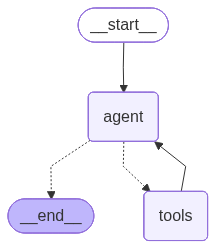

In [16]:
# ---------------------------------------------------
# 커스텀 워크플로우 생성 및 그래프 시각화
# ---------------------------------------------------
from IPython.display import Image, display

# 다중 서버를 사용하는 커스텀 워크플로우를 만들어요
mcp_workflow = run_async(create_mcp_workflow(multi_server_config))

# 커스텀 MCP 워크플로우 생성 완료!
# 그래프 구조:

# 그래프 흐름: START → agent → (tools_condition 분기) → tools → agent 루프 또는 END
# agent: LLM이 사용자 메시지를 분석하고 MCP 도구 호출 여부를 결정해요
# tools: ToolNode가 MCP 서버의 도구(날씨, 시간 등)를 실행하고 결과를 반환해요
# tools_condition: 도구 호출이 있으면 tools로, 없으면 END로 라우팅해요
display(Image(mcp_workflow.get_graph().draw_mermaid_png()))

In [17]:
# ---------------------------------------------------
# 커스텀 워크플로우 실행 테스트
# ---------------------------------------------------
workflow_thread_id = str(uuid.uuid4())
workflow_config = RunnableConfig(configurable={"thread_id": workflow_thread_id})

# ==================================================
# 커스텀 MCP 워크플로우 실행 중...
# ==================================================

async def run_mcp_workflow():
    # 현재 시간 조회 - agent 노드와 tools 노드가 번갈아 실행돼요
    async for chunk in mcp_workflow.astream(
        {"messages": [("human", "현재 시간을 알려주세요")], "context": {}},
        workflow_config,
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- [{node_name}] ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_mcp_workflow())


--- [agent] ---
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_ZEtgwVOG4scQI2zGjwiUSVIG)
 Call ID: call_ZEtgwVOG4scQI2zGjwiUSVIG
  Args:

--- [tools] ---
================================= Tool Message =================================
Name: get_current_time

[{'type': 'text', 'text': '현재 Asia/Seoul 시간: 2026-06-02 13:46:18 KST', 'id': 'lc_d308265a-41e2-40a7-b5d0-1d9b20c3169c'}]

--- [agent] ---
================================== Ai Message ==================================

현재 서울의 시간은 2026년 6월 2일 13시 46분 18초입니다.


---

## 6. 실습: 커스텀 MCP 에이전트 만들기

아래 실습 해설 블록을 완성하여 날씨와 시간을 **동시에** 물어보고 종합 보고서를 생성하는 에이전트를 만들어보세요.

> ⚠️ **자주 하는 실수**: 다중 질문을 한 번에 처리할 때는 에이전트가 **여러 도구를 순서대로 호출**해요. 이 과정을 스트리밍으로 확인하면서 각 노드가 어떻게 호출되는지 관찰해보세요.

In [18]:
# ============================================================
# 실습 해설: 복합 질문 처리 실습
#
# 아래 코드를 완성해서 에이전트에게 시간 + 날씨를 동시에 물어보세요.
# 힌트: mcp_workflow.astream()을 사용하고,
#       messages에 하나의 질문으로 두 가지를 동시에 물어보세요.
# 예상 결과: 에이전트가 시간 도구와 날씨 도구를 순서대로 호출해요.
# ============================================================

# 새로운 대화 스레드를 생성해요
practice_thread_id = str(uuid.uuid4())
practice_config = RunnableConfig(configurable={"thread_id": practice_thread_id})

# 실습 해설: 시간과 날씨를 동시에 물어보는 질문으로 변경해보세요
question = "현재 시간과 서울 날씨를 알려주고, 날씨에 맞는 옷차림을 추천해줘요."

# ==================================================
print(f"복합 질문: {question}")
# ==================================================

async def run_practice():
    # 실습 해설: 아래 코드를 채워서 mcp_workflow를 실행해보세요
    # (위 섹션의 코드를 참고하세요)
    async for chunk in mcp_workflow.astream(
        {"messages": [("human", question)], "context": {}},
        practice_config,
        stream_mode="updates",
    ):
        for node_name, node_output in chunk.items():
            print(f"\n--- [{node_name}] ---")
            if "messages" in node_output:
                for msg in node_output["messages"]:
                    msg.pretty_print()

run_async(run_practice())

복합 질문: 현재 시간과 서울 날씨를 알려주고, 날씨에 맞는 옷차림을 추천해줘요.

--- [agent] ---
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_w6f54shWoxGMcW7Rxi60bnA4)
 Call ID: call_w6f54shWoxGMcW7Rxi60bnA4
  Args:
    timezone: Asia/Seoul
  get_weather (call_bZ7n7hq6fEdYK6PNXev1QtWa)
 Call ID: call_bZ7n7hq6fEdYK6PNXev1QtWa
  Args:
    location: 서울

--- [tools] ---
================================= Tool Message =================================
Name: get_current_time

[{'type': 'text', 'text': '현재 Asia/Seoul 시간: 2026-06-02 13:46:20 KST', 'id': 'lc_f8b0e950-dbf4-4890-8526-541435ca36fd'}]
================================= Tool Message =================================
Name: get_weather

[{'type': 'text', 'text': "It's always Sunny in 서울", 'id': 'lc_c5fdb1f5-7f1f-45ed-805d-86ce7c60fd9c'}]

--- [agent] ---
================================== Ai Message ==================================

현재 서울의 시간은 **2026-06-02 13:46:20 KST**입니다. 

서울의 날씨는 **맑음**입니다. 

---

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`MultiServerMCPClient`**: 여러 MCP 서버를 하나로 묶어주는 통합 관리자. `get_tools()`로 모든 서버의 도구를 한 번에 가져와요
- **`setup_mcp_client` 헬퍼**: `server_configs` 딕셔너리로 stdio/HTTP 서버를 유연하게 설정해요
- **`create_agent` 방식**: 빠른 구현에 적합한 고수준 API. ReAct 루프를 자동으로 처리해요
- **`StateGraph` + `ToolNode` 방식**: 세밀한 제어가 필요할 때 사용. 각 노드의 동작을 직접 정의해요
- **`tools_condition`**: 도구 호출 여부에 따라 흐름을 분기하는 조건 함수예요
- **다중 서버 조합**: stdio 서버(로컬)와 HTTP 서버(원격)를 동시에 하나의 에이전트에서 활용할 수 있어요

## 다음 노트북 예고

다음 `08-MCP-Advanced-Servers.ipynb`에서는 **3rd Party MCP 서버 활용**을 배워요. Context7, npx 기반 외부 MCP 서버를 연결하고 복잡한 멀티-서버 워크플로우를 구성하는 방법을 살펴볼게요.